<div align="center">

# Predicción de tasas de mortalidad y natalidad a partir de indicadores socioeconómicos

**Proyecto Integrador**

Universidad Internacional del Ecuador — UIDE

---

**Notebook 01 — Análisis Exploratorio de Datos (EDA)**

---

Equipo: Guillermo Paredes · Donato Oña · Mateo Villacreses

Junio 2026

</div>

## Objetivo

Caracterizar el comportamiento de las **tasas brutas de mortalidad y natalidad** de los países del mundo y su relación con un conjunto de indicadores socioeconómicos, con el fin de fundamentar la formulación del problema de aprendizaje automático que se aborda en los notebooks posteriores.

## Fuente de datos

Los datos provienen del **World Bank Open Data** (<https://data.worldbank.org>), accedidos mediante el cliente oficial `wbgapi`. Este enfoque garantiza la reproducibilidad del análisis: cualquier integrante del equipo regenera el dataset ejecutando el notebook, sin necesidad de versionar archivos pesados en el repositorio.

## Estructura del notebook

1. Configuración inicial y selección de indicadores.
2. Adquisición y limpieza del dataset.
3. Filtrado de agregados regionales y enriquecimiento con metadatos.
4. Inspección de la calidad de los datos y análisis de valores faltantes.
5. Análisis univariado de las variables objetivo.
6. Análisis de correlaciones entre predictores y targets.
7. Conclusiones y formulación del problema de aprendizaje automático.

## 1. Configuración inicial

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wbgapi as wb

# Estilo de gráficos
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (10, 6)

# Pandas display
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)


## 2. Selección de indicadores

Se trabajan dos **variables objetivo** —tasa bruta de mortalidad y tasa bruta de natalidad, ambas medidas en eventos por cada 1.000 habitantes— y ocho **predictores** que cubren las dimensiones económica y social del desarrollo de un país. La selección busca un balance entre cobertura temporal en la API del Banco Mundial y relevancia teórica respecto al fenómeno demográfico estudiado.

In [2]:
INDICATORS = {
    # === 🎯 Variables objetivo (lo que queremos predecir) ===
    'SP.DYN.CDRT.IN':    'death_rate',           # Tasa bruta de mortalidad (por 1.000 hab.)
    'SP.DYN.CBRT.IN':    'birth_rate',           # Tasa bruta de natalidad (por 1.000 hab.)

    # === 💰 Predictores económicos ===
    'NY.GDP.PCAP.CD':    'gdp_per_capita',       # PIB per cápita (US$ actuales)
    'NY.GDP.MKTP.KD.ZG': 'gdp_growth',           # Crecimiento del PIB (% anual)
    'SI.POV.GINI':       'gini',                 # Coeficiente de Gini
    'SL.UEM.TOTL.ZS':    'unemployment',         # Desempleo (% fuerza laboral)

    # === 🏛️ Predictores sociales ===
    'SH.XPD.CHEX.GD.ZS': 'health_exp_pct_gdp',   # Gasto en salud (% del PIB)
    'SE.XPD.TOTL.GD.ZS': 'edu_exp_pct_gdp',      # Gasto en educación (% del PIB)
    'SP.URB.TOTL.IN.ZS': 'urban_pop_pct',        # Población urbana (% del total)
    'SP.POP.TOTL':       'population',           # Población total
}

TARGETS = ['death_rate', 'birth_rate']
FEATURES = [v for v in INDICATORS.values() if v not in TARGETS]

# Rango temporal
YEAR_START, YEAR_END = 2000, 2022  # 2022 suele ser el último año con buena cobertura

print(f"Indicadores: {len(INDICATORS)}")
print(f"  - Targets:    {TARGETS}")
print(f"  - Features:   {FEATURES}")
print(f"Rango temporal: {YEAR_START}–{YEAR_END}")

Indicadores: 10
  - Targets:    ['death_rate', 'birth_rate']
  - Features:   ['gdp_per_capita', 'gdp_growth', 'gini', 'unemployment', 'health_exp_pct_gdp', 'edu_exp_pct_gdp', 'urban_pop_pct', 'population']
Rango temporal: 2000–2022


## 3. Adquisición del dataset

La consulta recupera todos los indicadores para todas las economías reportadas por el Banco Mundial en el rango temporal seleccionado, en una única llamada a la API.

In [3]:
# Descargar datos para todos los países (incluye agregados, los filtramos después)
df_raw = wb.data.DataFrame(
    series=list(INDICATORS.keys()),
    economy='all',
    time=range(YEAR_START, YEAR_END + 1),
    columns='series',
    skipBlanks=False,
    labels=False,
)

print(f"Shape inicial: {df_raw.shape}")
df_raw.head()

Shape inicial: (6118, 10)


NY.GDP.MKTP.KD.ZG  NY.GDP.PCAP.CD  SE.XPD.TOTL.GD.ZS  SH.XPD.CHEX.GD.ZS  SI.POV.GINI  SL.UEM.TOTL.ZS  \
economy time                                                                                                           
ABW     YR2000           7.622921    20681.023027            4.71468                NaN          NaN             NaN   
        YR2001           4.182002    20740.132583            4.79898                NaN          NaN             NaN   
        YR2002          -0.944953    21307.248251            4.87220                NaN          NaN             NaN   
        YR2003           1.110505    21949.485996                NaN                NaN          NaN             NaN   
        YR2004           7.293728    23700.631990            4.35699                NaN          NaN             NaN   

                SP.DYN.CBRT.IN  SP.DYN.CDRT.IN  SP.POP.TOTL  SP.URB.TOTL.IN.ZS  
economy time                                                                    
ABW     YR2000          14.260           5.850      90588.0          65.354550  
        YR2001          13.813           4.757      91439.0          65.335114  
        YR2002          13.337           5.344      92074.0          65.282069  
        YR2003          13.358           5.380      93128.0          65.198292  
        YR2004          12.540           5.277      95138.0          65.088653

El DataFrame devuelto presenta un índice multinivel `(economy, time)` —donde la dimensión temporal se codifica como `YR2000`, `YR2001`, etc.— y como columnas los códigos crudos de los indicadores. Se reestructura a un formato tabular plano con nombres legibles.

In [4]:
# Aplanar el índice multinivel
df = df_raw.reset_index()

# Convertir 'YR2000' → 2000
df['year'] = df['time'].str.replace('YR', '').astype(int)
df = df.drop(columns='time')

# Renombrar columna 'economy' → 'country_code' y los códigos de indicadores a nombres amigables
df = df.rename(columns={'economy': 'country_code', **INDICATORS})

# Reordenar columnas
cols_order = ['country_code', 'year'] + list(INDICATORS.values())
df = df[cols_order]

print(f"Shape: {df.shape}")
df.head()

Shape: (6118, 12)


,country_code,year,death_rate,birth_rate,gdp_per_capita,gdp_growth,gini,unemployment,health_exp_pct_gdp,edu_exp_pct_gdp,urban_pop_pct,population
0,ABW,2000,5.850,14.260,20681.023027,7.622921,NaN,NaN,NaN,4.71468,65.354550,90588.0
1,ABW,2001,4.757,13.813,20740.132583,4.182002,NaN,NaN,NaN,4.79898,65.335114,91439.0
2,ABW,2002,5.344,13.337,21307.248251,-0.944953,NaN,NaN,NaN,4.87220,65.282069,92074.0
3,ABW,2003,5.380,13.358,21949.485996,1.110505,NaN,NaN,NaN,NaN,65.198292,93128.0
4,ABW,2004,5.277,12.540,23700.631990,7.293728,NaN,NaN,NaN,4.35699,65.088653,95138.0


## 4. Filtrado de agregados regionales

La API del Banco Mundial mezcla **países individuales** con **agregados regionales** (por ejemplo `WLD` para el mundo, `EUU` para la Unión Europea, `LAC` para América Latina y el Caribe). Para un análisis comparativo entre países es necesario excluir los agregados.

El cliente `wbgapi` identifica los agregados por su atributo `region`, que toma el valor `NA` para entidades que no son países. Se enriquece adicionalmente cada observación con el nombre del país, la región y el nivel de ingreso.

In [5]:
# Traer metadata de economías: nombre, región, nivel de ingreso
economies = pd.DataFrame([
    {'country_code': e['id'], 'country_name': e['value'], 'region': e['region'], 'income_level': e['incomeLevel']}
    for e in wb.economy.list()
])

print(f"Total entidades en la API: {len(economies)}")
print(f"Agregados (sin región): {(economies['region'] == 'NA').sum()}")
print(f"Países individuales:    {(economies['region'] != 'NA').sum()}")
economies.head()

Total entidades en la API: 266
Agregados (sin región): 0
Países individuales:    266


,country_code,country_name,region,income_level
0,ABW,Aruba,LCN,HIC
1,AFE,Africa Eastern and Southern,,
2,AFG,Afghanistan,MEA,LIC
3,AFW,Africa Western and Central,,
4,AGO,Angola,SSF,LMC


In [6]:
# Merge con la metadata y filtrar solo países (no agregados)
df = df.merge(economies, on='country_code', how='left')
df = df[df['region'] != 'NA'].copy()

# Reordenar para que las columnas de metadata vengan primero
meta_cols = ['country_code', 'country_name', 'region', 'income_level', 'year']
value_cols = [c for c in df.columns if c not in meta_cols]
df = df[meta_cols + value_cols].reset_index(drop=True)

print(f"Shape final: {df.shape}")
print(f"Países únicos: {df['country_code'].nunique()}")
print(f"Años: {df['year'].min()}–{df['year'].max()}")
df.head()

Shape final: (6118, 15)
Países únicos: 266
Años: 2000–2022


,country_code,country_name,region,income_level,year,death_rate,birth_rate,gdp_per_capita,gdp_growth,gini,unemployment,health_exp_pct_gdp,edu_exp_pct_gdp,urban_pop_pct,population
0,ABW,Aruba,LCN,HIC,2000,5.850,14.260,20681.023027,7.622921,NaN,NaN,NaN,4.71468,65.354550,90588.0
1,ABW,Aruba,LCN,HIC,2001,4.757,13.813,20740.132583,4.182002,NaN,NaN,NaN,4.79898,65.335114,91439.0
2,ABW,Aruba,LCN,HIC,2002,5.344,13.337,21307.248251,-0.944953,NaN,NaN,NaN,4.87220,65.282069,92074.0
3,ABW,Aruba,LCN,HIC,2003,5.380,13.358,21949.485996,1.110505,NaN,NaN,NaN,NaN,65.198292,93128.0
4,ABW,Aruba,LCN,HIC,2004,5.277,12.540,23700.631990,7.293728,NaN,NaN,NaN,4.35699,65.088653,95138.0


## 5. Persistencia del dataset crudo

Se guarda el dataset en `data/raw/` en formato Parquet para mantener una copia local del estado inicial de los datos. Dado que la carpeta `data/` está incluida en `.gitignore`, el archivo no se versiona en el repositorio: cada integrante del equipo lo regenera ejecutando este notebook.

In [7]:
import os

os.makedirs('../data/raw', exist_ok=True)
output_path = '../data/raw/worldbank_indicators.parquet'
df.to_parquet(output_path, index=False)

print(f"✅ Dataset crudo guardado en {output_path}")
print(f"   Shape: {df.shape}")
print(f"   Tamaño: {os.path.getsize(output_path) / 1024:.1f} KB")

✅ Dataset crudo guardado en ../data/raw/worldbank_indicators.parquet
   Shape: (6118, 15)
   Tamaño: 417.2 KB


---
## 6. Inspección inicial

In [8]:
print("=== INFO ===")
df.info()
print("\n=== DESCRIBE (numéricas) ===")
df[value_cols].describe().T

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6118 entries, 0 to 6117
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country_code        6118 non-null   object 
 1   country_name        6118 non-null   object 
 2   region              6118 non-null   object 
 3   income_level        6118 non-null   object 
 4   year                6118 non-null   int64  
 5   death_rate          6095 non-null   float64
 6   birth_rate          6095 non-null   float64
 7   gdp_per_capita      5942 non-null   float64
 8   gdp_growth          5868 non-null   float64
 9   gini                1776 non-null   float64
 10  unemployment        5404 non-null   float64
 11  health_exp_pct_gdp  5452 non-null   float64
 12  edu_exp_pct_gdp     4128 non-null   float64
 13  urban_pop_pct       6095 non-null   float64
 14  population          6095 non-null   float64
dtypes: float64(10), int64(1), object(4)
memory

,count,mean,std,min,25%,50%,75%,max
death_rate,6095.0,8.231706e+00,3.239922e+00,0.841000,6.200000e+00,7.715000e+00,9.760000e+00,7.248300e+01
birth_rate,6095.0,2.159728e+01,1.080873e+01,4.400000,1.220000e+01,1.887600e+01,2.932750e+01,5.339000e+01
gdp_per_capita,5942.0,1.449263e+04,2.286998e+04,109.593814,1.525201e+03,4.911769e+03,1.820556e+04,2.260520e+05
gdp_growth,5868.0,3.439639e+00,5.549382e+00,-54.402093,1.461378e+00,3.708321e+00,5.899524e+00,8.682675e+01
gini,1776.0,3.678570e+01,8.133979e+00,23.200000,3.070000e+01,3.500000e+01,4.150000e+01,6.500000e+01
unemployment,5404.0,7.811495e+00,5.491483e+00,0.100000,4.153000e+00,6.282953e+00,9.873068e+00,3.732000e+01
health_exp_pct_gdp,5452.0,6.162567e+00,2.790093e+00,1.222602,4.189067e+00,5.417430e+00,7.774243e+00,2.445763e+01
edu_exp_pct_gdp,4128.0,4.271059e+00,1.792974e+00,0.000004,3.096802e+00,4.061260e+00,5.082541e+00,1.623038e+01
urban_pop_pct,6095.0,5.782423e+01,2.303321e+01,8.043814,3.887809e+01,5.714086e+01,7.663494e+01,1.000000e+02
population,6095.0,2.850734e+08,8.906825e+08,9544.000000,1.425332e+06,9.604924e+06,5.968833e+07,7.989545e+09


### 6.1 Valores faltantes

Los datos del Banco Mundial presentan una proporción considerable de valores faltantes, especialmente en indicadores cuya recolección depende de encuestas nacionales puntuales (Gini, gasto en educación) o de reportes voluntarios. Cuantificar este patrón es indispensable antes de decidir la estrategia de imputación que se aplicará en el siguiente notebook.

In [9]:
missing = pd.DataFrame({
    'n_missing': df[value_cols].isna().sum(),
    'pct_missing': (df[value_cols].isna().mean() * 100).round(2),
}).sort_values('pct_missing', ascending=False)

missing

,n_missing,pct_missing
gini,4342,70.97
edu_exp_pct_gdp,1990,32.53
unemployment,714,11.67
health_exp_pct_gdp,666,10.89
gdp_growth,250,4.09
gdp_per_capita,176,2.88
birth_rate,23,0.38
death_rate,23,0.38
urban_pop_pct,23,0.38
population,23,0.38


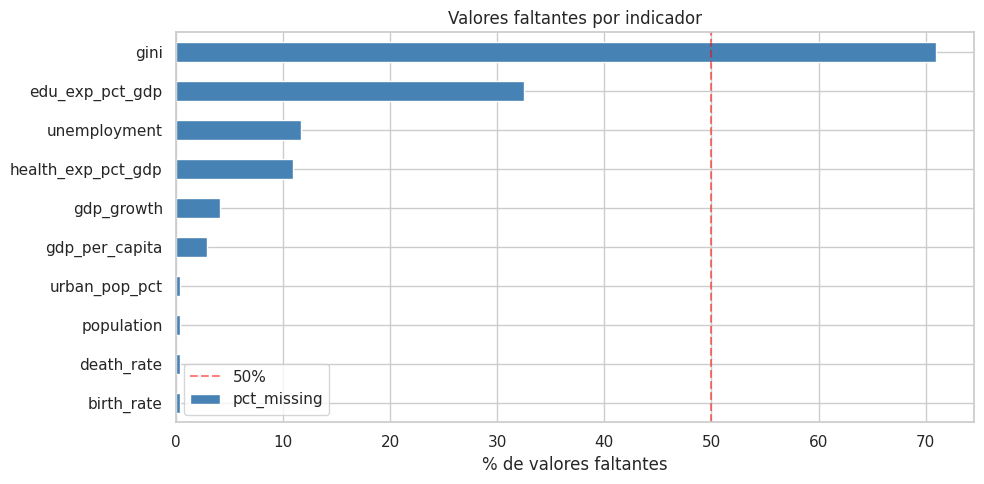

In [10]:
# Visualización de faltantes
fig, ax = plt.subplots(figsize=(10, 5))
missing['pct_missing'].sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Valores faltantes por indicador')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50%')
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Cobertura por año

La completitud no es uniforme a lo largo del rango temporal. Los años centrales del período concentran mayor cobertura, mientras que el extremo más reciente sufre rezagos típicos en la publicación de estadísticas oficiales.

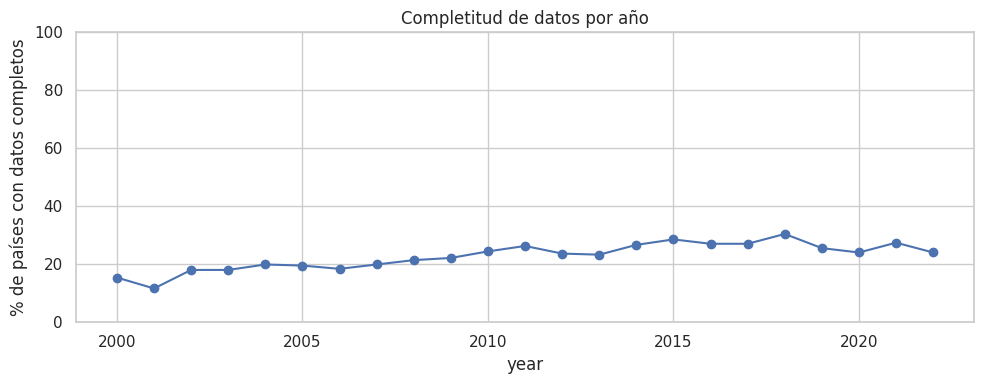

Año con mayor completitud: 2018 (30.5%)


In [11]:
# % filas con todos los indicadores presentes, por año
complete_by_year = (
    df.set_index(['country_code', 'year'])[value_cols]
      .notna().all(axis=1)
      .groupby('year').mean() * 100
)

fig, ax = plt.subplots(figsize=(10, 4))
complete_by_year.plot(ax=ax, marker='o')
ax.set_ylabel('% de países con datos completos')
ax.set_title('Completitud de datos por año')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

print(f"Año con mayor completitud: {complete_by_year.idxmax()} ({complete_by_year.max():.1f}%)")

## 7. Análisis de las variables objetivo

Se examina la distribución de las tasas de mortalidad y natalidad, su comportamiento por región y su evolución temporal. Este análisis informa la elección entre un enfoque de regresión o de clasificación para el modelado posterior.

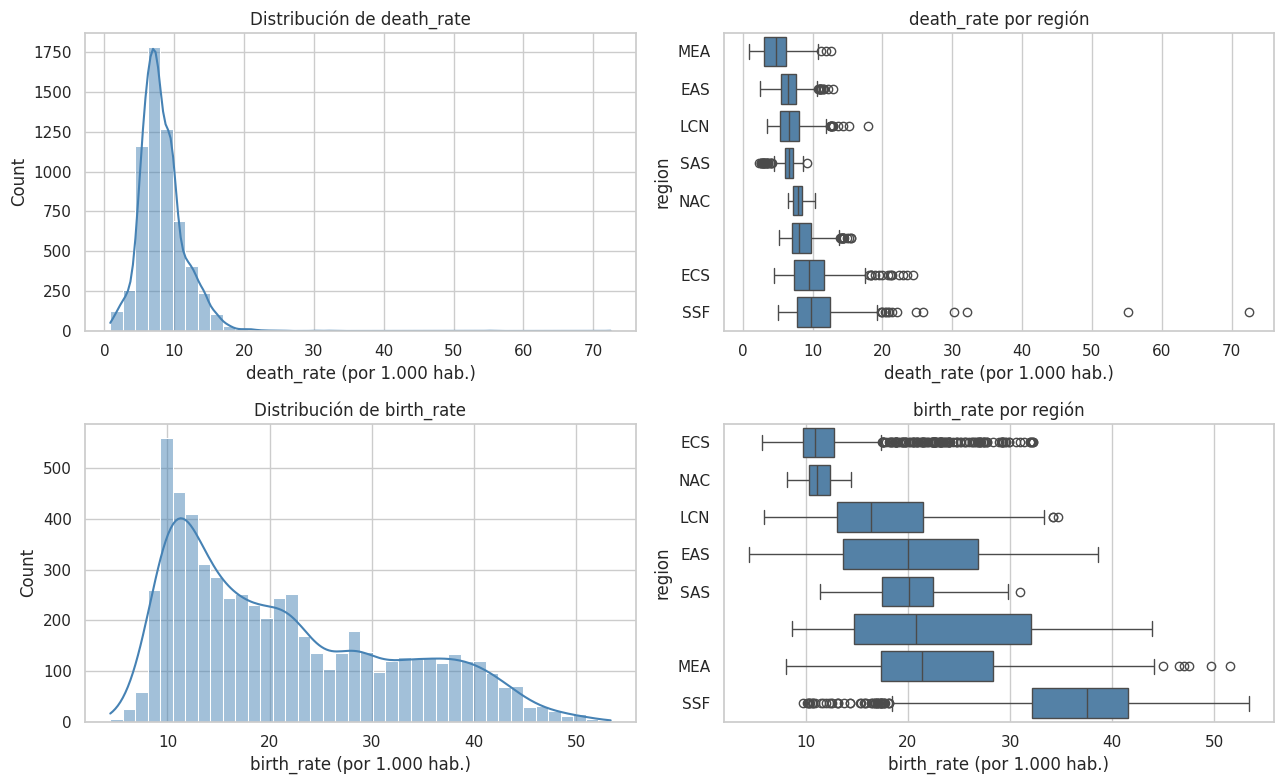


Resumen estadístico de los targets:
             count       mean        std    min     50%     max
death_rate  6095.0   8.231706   3.239922  0.841   7.715  72.483
birth_rate  6095.0  21.597282  10.808728  4.400  18.876  53.390


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Distribuciones
for i, target in enumerate(TARGETS):
    sns.histplot(df[target].dropna(), bins=40, kde=True, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'Distribución de {target}')
    axes[i, 0].set_xlabel(f'{target} (por 1.000 hab.)')
    
    # Boxplot por región
    order = df.groupby('region')[target].median().sort_values().index
    sns.boxplot(data=df, y='region', x=target, ax=axes[i, 1], order=order, color='steelblue')
    axes[i, 1].set_title(f'{target} por región')
    axes[i, 1].set_xlabel(f'{target} (por 1.000 hab.)')

plt.tight_layout()
plt.show()

print("\nResumen estadístico de los targets:")
print(df[TARGETS].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])

### 7.1 Evolución temporal por región

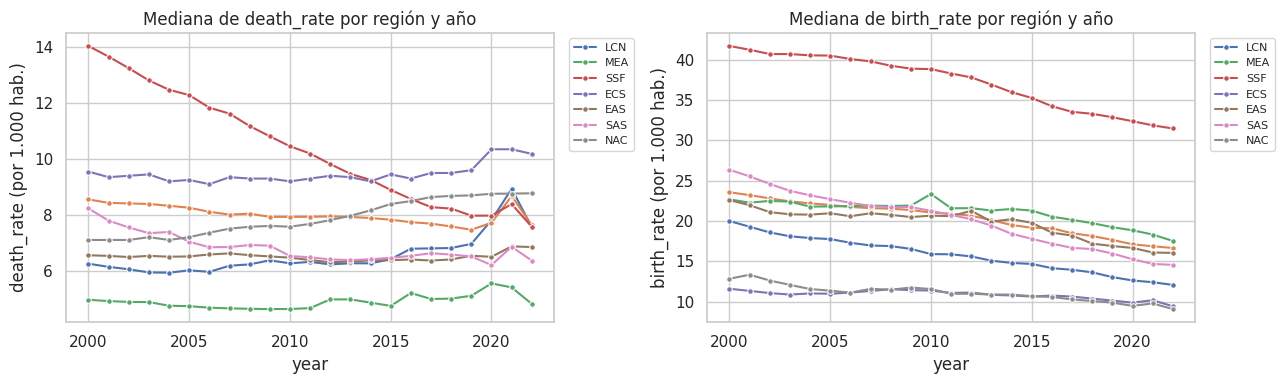

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, target in zip(axes, TARGETS):
    sns.lineplot(data=df, x='year', y=target, hue='region', estimator='median',
                 errorbar=None, ax=ax, marker='o', markersize=4)
    ax.set_title(f'Mediana de {target} por región y año')
    ax.set_ylabel(f'{target} (por 1.000 hab.)')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 8. Análisis de correlaciones

Se utiliza el **coeficiente de correlación de Spearman** (basado en rangos), que captura relaciones monótonas no necesariamente lineales y es robusto frente a sesgos pronunciados —presentes en variables como PIB per cápita o población—. Esto lo hace más apropiado que el coeficiente de Pearson para el conjunto de indicadores trabajado.

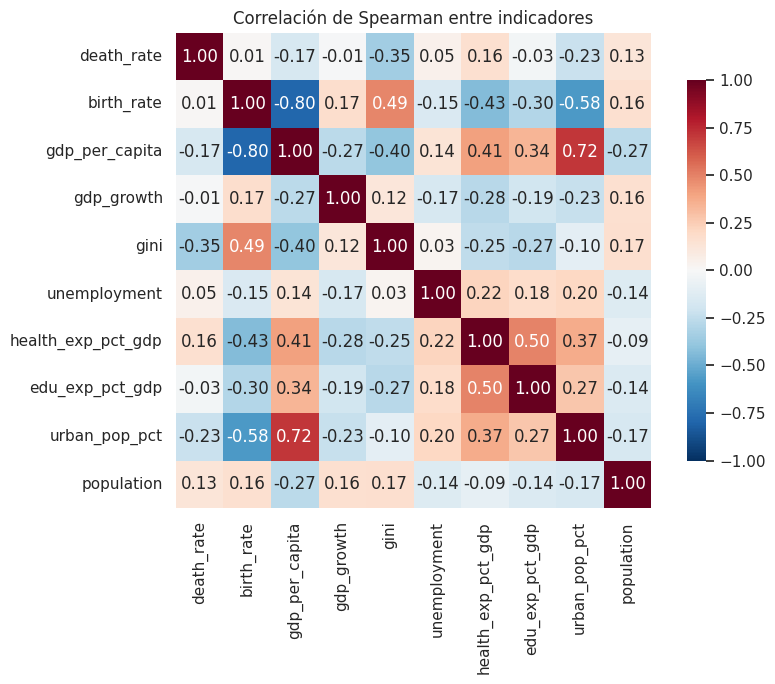

In [14]:
corr = df[value_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlación de Spearman entre indicadores')
plt.tight_layout()
plt.show()

In [15]:
# Top predictores correlacionados con cada target
print("Predictores ordenados por correlación absoluta con cada target:\n")
for target in TARGETS:
    print(f"--- {target} ---")
    target_corr = corr[target].drop(TARGETS).abs().sort_values(ascending=False)
    for feat, val in target_corr.items():
        signo = '+' if corr.loc[feat, target] > 0 else '-'
        print(f"  {signo} {feat:25s}: {val:.3f}")
    print()

Predictores ordenados por correlación absoluta con cada target:

--- death_rate ---
  - gini                     : 0.348
  - urban_pop_pct            : 0.226
  - gdp_per_capita           : 0.165
  + health_exp_pct_gdp       : 0.157
  + population               : 0.131
  + unemployment             : 0.051
  - edu_exp_pct_gdp          : 0.031
  - gdp_growth               : 0.011

--- birth_rate ---
  - gdp_per_capita           : 0.795
  - urban_pop_pct            : 0.578
  + gini                     : 0.488
  - health_exp_pct_gdp       : 0.434
  - edu_exp_pct_gdp          : 0.296
  + gdp_growth               : 0.173
  + population               : 0.160
  - unemployment             : 0.152



### 8.1 Relaciones bivariadas con los predictores principales

Para cada variable objetivo se visualizan los tres predictores con mayor correlación absoluta. Las variables con escala muy sesgada (PIB per cápita, población) se representan en escala logarítmica para facilitar la interpretación.

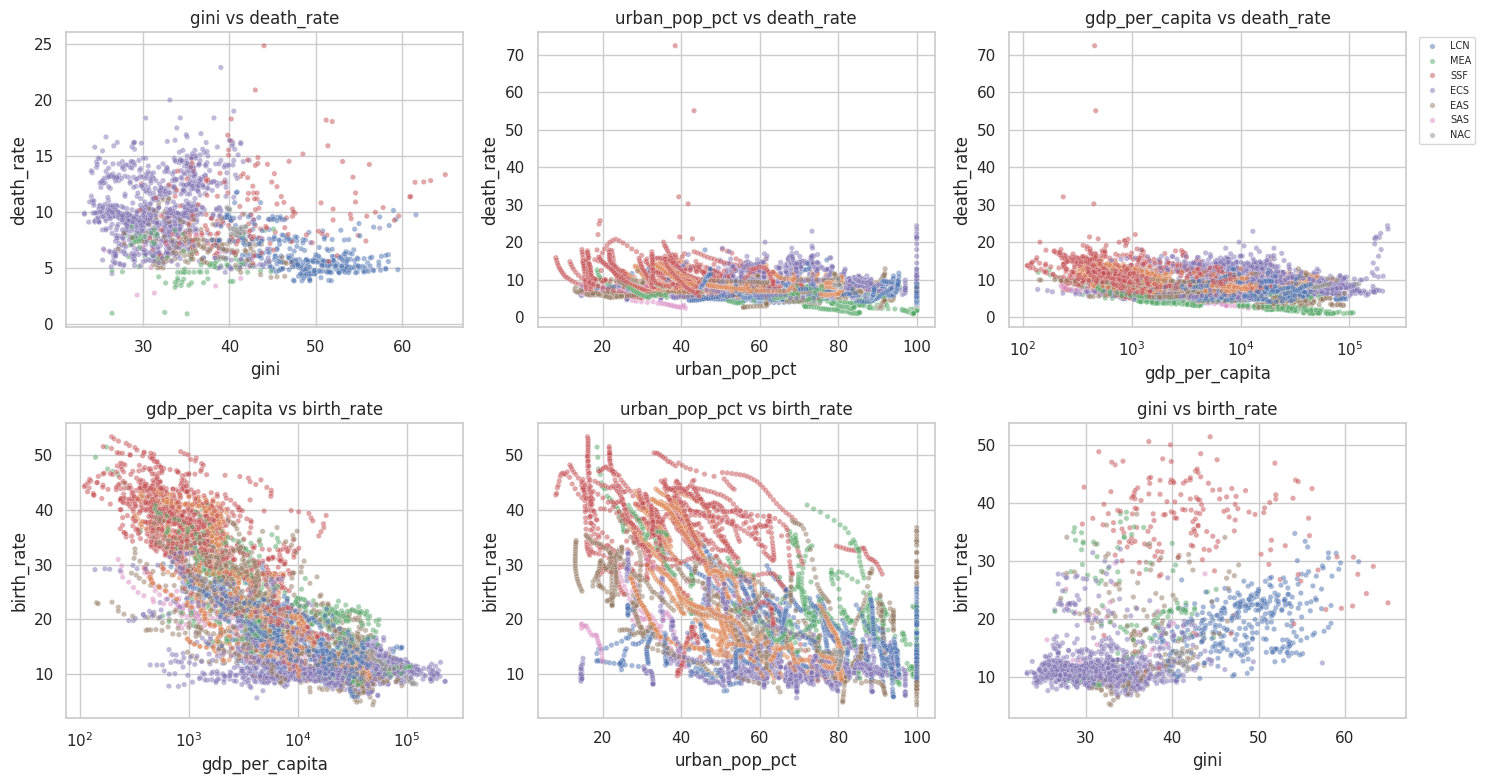

In [16]:
# Para cada target, top 3 predictores más correlacionados
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row, target in enumerate(TARGETS):
    top_feats = corr[target].drop(TARGETS).abs().sort_values(ascending=False).head(3).index
    for col, feat in enumerate(top_feats):
        sns.scatterplot(data=df, x=feat, y=target, hue='region', ax=axes[row, col],
                       alpha=0.5, s=15, legend=(row == 0 and col == 2))
        # Escala log para PIB y población
        if feat in ['gdp_per_capita', 'population']:
            axes[row, col].set_xscale('log')
        axes[row, col].set_title(f'{feat} vs {target}')
        if row == 0 and col == 2:
            axes[row, col].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.show()

## 9. Conclusiones y formulación del problema de ML

### Hallazgos principales

- **Cobertura de datos.** El dataset agrupa varias decenas de países a lo largo de más de dos décadas, pero la completitud por celda no es homogénea: indicadores socioeconómicos clave como el coeficiente de Gini y el gasto en educación presentan proporciones de valores faltantes muy superiores al resto, mientras que las variables demográficas (mortalidad, natalidad, población, urbanización) están casi siempre disponibles.
- **Distribuciones de los targets.** Las tasas de mortalidad y natalidad son variables continuas, no negativas, con distribuciones moderadamente sesgadas a la derecha. La natalidad muestra una varianza significativamente mayor entre regiones que la mortalidad.
- **Patrones regionales.** Existe una estratificación clara por región y por nivel de ingreso. África Subsahariana concentra los valores más altos de natalidad; Europa y Asia Central, los más bajos. La mortalidad presenta un patrón menos lineal: las regiones con poblaciones envejecidas (Europa) muestran tasas relativamente altas a pesar de su alto desarrollo.
- **Estructura temporal.** Cada país aparece en múltiples años, generando una estructura de **datos panel**. Esto introduce dependencia entre observaciones del mismo país que debe respetarse en la separación entre conjuntos de entrenamiento y prueba.
- **Predictores más informativos.** El PIB per cápita, el porcentaje de población urbana y el gasto en salud presentan las correlaciones absolutas más altas con ambos targets. Las relaciones son monótonas pero no lineales en escala original, lo que justifica transformaciones logarítmicas para las variables económicas y demográficas.

### Formulación del problema

Dado que las variables objetivo son **continuas** y se busca obtener una predicción numérica de la tasa, el problema se formula como una tarea de **regresión supervisada**. Se contemplan tres enfoques:

1. **Regresión independiente por target** — entrenar un modelo separado para mortalidad y otro para natalidad. Es el enfoque base y permite optimizar cada modelo según las particularidades de su variable.
2. **Regresión multi-salida** — un único modelo que predice ambos targets simultáneamente, aprovechando su correlación.
3. **Clasificación por bucketización** — discretizar las tasas en categorías (baja/media/alta). Se descarta como enfoque principal por la pérdida de información que implica, pero queda como variante para evaluación de zonas de riesgo si el caso de uso lo requiere.

**Decisión inicial:** se adopta el enfoque (1) como línea base, comenzando con regresión lineal regularizada (Ridge/Lasso) y comparándola contra modelos basados en árboles (XGBoost, LightGBM). La estructura panel del dataset exigirá una separación entrenamiento/prueba que respete la dimensión temporal o que agrupe por país.
